In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (23).zip to archive (23).zip


In [52]:
import zipfile
import os

zip_file_name = list(uploaded.keys())[0]

extract_path = "/content/emotion_data"

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [53]:
#paths of train and test data
train_dir = "/content/emotion_data/train"
test_dir = "/content/emotion_data/test"

In [54]:
!pip install -q tensorflow opencv-python matplotlib

In [55]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

In [56]:
from tensorflow.keras.preprocessing import image


In [57]:
def apply_all_techniques(image, label):
    image = tf.cast(image, tf.float32) / 255.0

  # contrast
    image = tf.image.adjust_contrast(image, 2.0)

  # gamma
    image = tf.image.adjust_gamma(image, 0.8)

# negative
    image = 1.0 - image


#  removing all non values
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, label

In [64]:
for class_name in os.listdir(train_dir):
    print(class_name, len(os.listdir(os.path.join(train_dir, class_name))))

sad 4830
fearful 4097
neutral 4965
angry 3995
disgusted 436
surprised 3171
happy 7215


In [65]:
# loading Dataset

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(48, 48),
    batch_size=32,
    color_mode="grayscale",
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(48, 48),
    batch_size=32,
    color_mode="grayscale",
    shuffle=False
)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


In [66]:
#rescalling
tf.keras.layers.Rescaling(1./1)

<Rescaling name=rescaling_6, built=False>

In [67]:
#learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

In [68]:
input_shape = (48, 48, 1)

In [69]:
# check classes names

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Number of classes: 7


In [70]:
# Building a model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48,48,1)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

In [71]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [72]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,    # stop if val_loss does not improve for 3 epochs
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 106s 116ms/step - accuracy: 0.3273 - loss: 1.7795 - val_accuracy: 0.4128 - val_loss: 1.5537
Epoch 2/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 103s 114ms/step - accuracy: 0.4226 - loss: 1.4864 - val_accuracy: 0.4568 - val_loss: 1.4186
Epoch 3/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 104s 116ms/step - accuracy: 0.4634 - loss: 1.4016 - val_accuracy: 0.4785 - val_loss: 1.3634
Epoch 4/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 104s 116ms/step - accuracy: 0.4917 - loss: 1.3330 - val_accuracy: 0.4777 - val_loss: 1.3491
Epoch 5/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 143s 117ms/step - accuracy: 0.5107 - loss: 1.2787 - val_accuracy: 0.5092 - val_loss: 1.2941
Epoch 6/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 107s 119ms/step - accuracy: 0.5294 - loss: 1.2306 - val_accuracy: 0.5106 - val_loss: 1.2777
Epoch 7/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 103s 114ms/step - accuracy: 0.5503 - loss: 1.1786 - val_accuracy: 0.5107 - val_loss: 1.3314
Epoch 8/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 142s 115ms/step - accuracy: 0.5708 -

In [73]:
loss, acc = model.evaluate(test_dataset)
print("Accuracy:", acc)

225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5106 - loss: 1.2777
Accuracy: 0.5105879306793213


In [74]:
model.save("emotion_model.keras")
print("Model saved successfully")

Model saved successfully


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


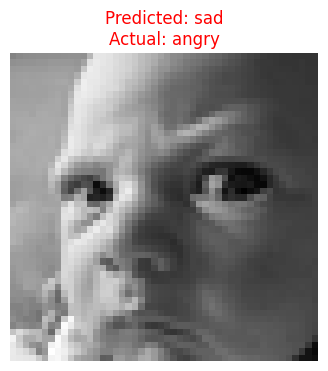

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


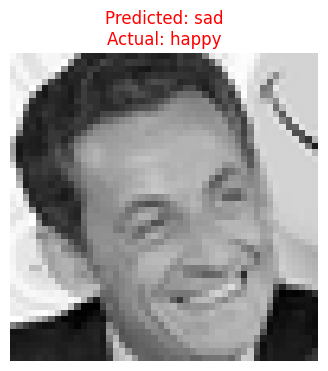

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


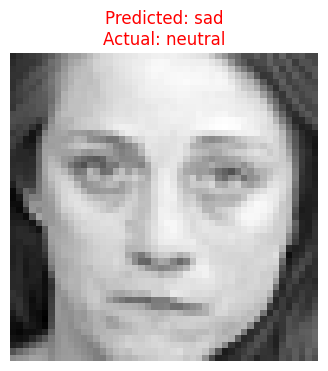

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


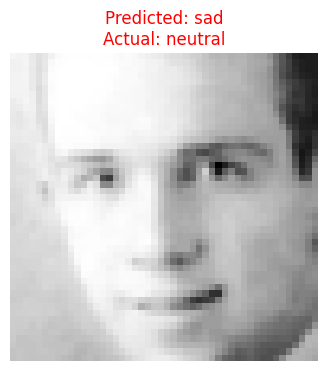

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


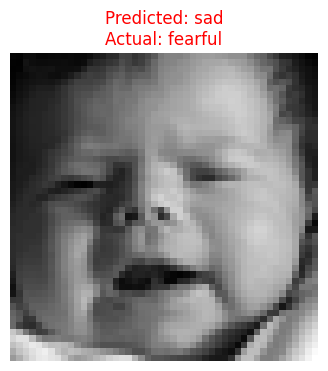

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


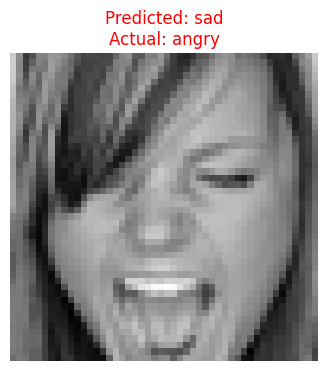

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


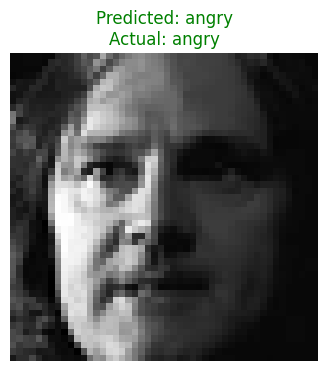

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


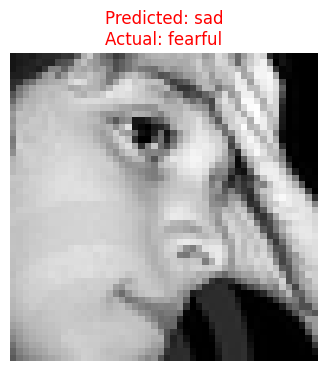

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


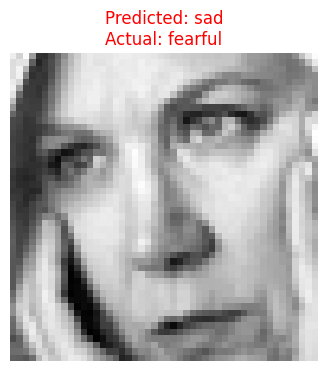

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


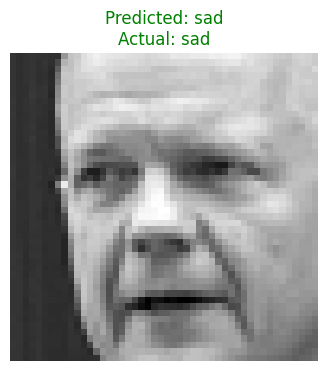

In [76]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

num_random_images = 10

for _ in range(num_random_images):
    # Pick a random class
    random_class = np.random.choice(class_names)
    class_folder = os.path.join(test_dir, random_class)

    # Pick a random image from that class
    img_file = np.random.choice(os.listdir(class_folder))
    img_path = os.path.join(class_folder, img_file)

    # Load image, convert to grayscale, and resize
    img = Image.open(img_path).convert('L').resize((48,48))

    # Convert to numpy array and normalize
    img_array = np.array(img)/255.0

    # Add batch and channel dimensions for model input
    img_array = np.expand_dims(img_array, axis=(0,-1))  # shape: (1,48,48,1)

    # Predict class
    pred = model.predict(img_array)
    predicted_label = class_names[np.argmax(pred)]

    # Display the image
    plt.figure(figsize=(4,4))
    plt.imshow(img_array[0,:,:,0], cmap='gray')

    # Color title: green if correct, red if wrong
    color = 'green' if predicted_label == random_class else 'red'
    plt.title(f"Predicted: {predicted_label}\nActual: {random_class}", fontsize=12, color=color)
    plt.axis('off')
    plt.show()